Mounted at /content/drive
Generating THESIS version (no panel titles)


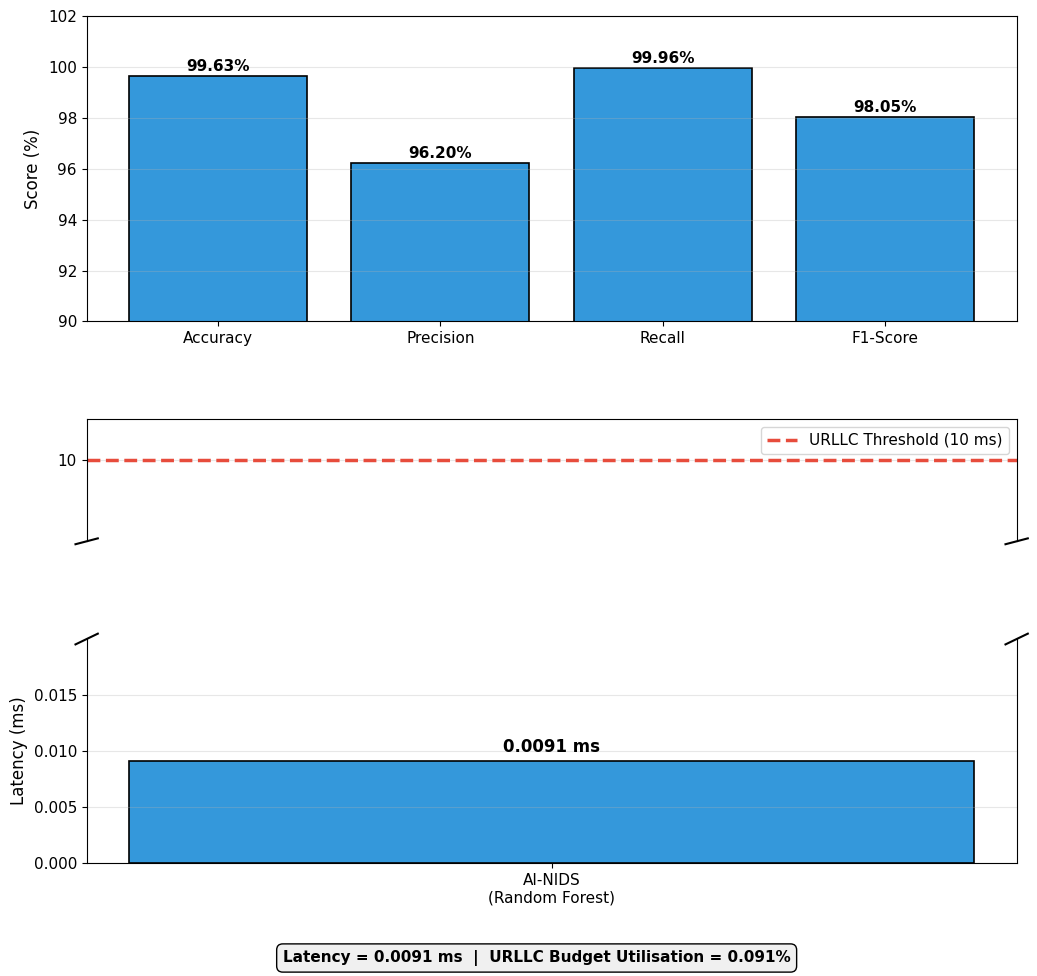

Saved: /content/drive/MyDrive/veremi_thesis/figure_baseline_thesis.png

Generating GITHUB version (with panel titles)


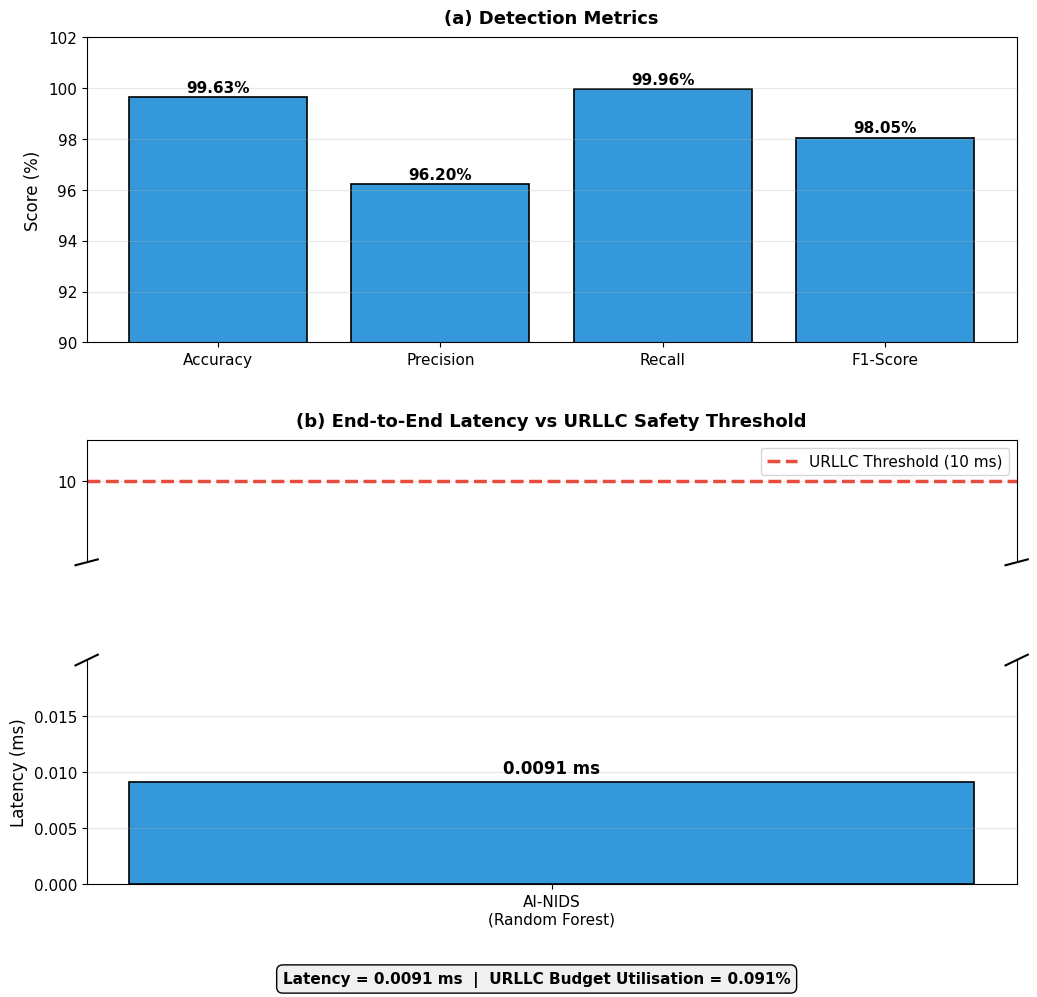

Saved: /content/drive/MyDrive/veremi_thesis/figure_baseline_github.png

BOTH VERSIONS GENERATED SUCCESSFULLY


In [1]:
# ============================================================
# Figure 13: Baseline AI-NIDS Performance Metrics
# Two versions: thesis (no titles) and github (with titles)
# ============================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# ============================================================
# CONFIGURATION
# ============================================================
BASELINE_COLOR = "#3498db"
THRESHOLD_COLOR = "#e74c3c"

# Locked empirical values (from Google Colab evaluation)
baseline_metrics = [99.6277, 96.2045, 99.9626, 98.0476]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
baseline_latency = 0.0091  # ms (Random Forest inference latency)
urllc_threshold = 10.0      # ms (V2X URLLC safety threshold)


def generate_baseline_figure(include_titles, output_filename):
    """
    Generate the Figure 13 baseline performance visualisation.

    Args:
        include_titles: If True, includes (a) and (b) panel titles (GitHub version).
                        If False, omits titles for cleaner thesis presentation.
        output_filename: Full path to save the PNG file.
    """

    # Create figure with custom GridSpec layout (3 rows for broken y-axis)
    fig = plt.figure(figsize=(12, 11))
    gs = GridSpec(3, 1, figure=fig, height_ratios=[3, 1.2, 2.2], hspace=0.45)

    # ==========================================
    # TOP PANEL: Detection Metrics Bar Chart
    # ==========================================
    ax1 = fig.add_subplot(gs[0])
    bars1 = ax1.bar(metric_labels, baseline_metrics, color=BASELINE_COLOR,
                    edgecolor="black", linewidth=1.2)
    ax1.set_ylabel("Score (%)", fontsize=12)
    if include_titles:
        ax1.set_title("(a) Detection Metrics", fontsize=13, fontweight="bold", pad=10)
    ax1.set_ylim(90, 102)
    ax1.grid(axis="y", alpha=0.3)
    ax1.tick_params(axis='both', labelsize=11)
    for bar, val in zip(bars1, baseline_metrics):
        ax1.text(bar.get_x() + bar.get_width()/2, val + 0.2,
                 f"{val:.2f}%", ha="center", fontsize=11, fontweight="bold")

    # ==========================================
    # MIDDLE PANEL: Upper latency view (URLLC threshold zone, 8-11 ms)
    # ==========================================
    ax2_upper = fig.add_subplot(gs[1])
    ax2_upper.bar(["AI-NIDS\n(Random Forest)"], [baseline_latency],
                  color=BASELINE_COLOR, edgecolor="black", linewidth=1.2, width=0.4)
    ax2_upper.axhline(y=urllc_threshold, color=THRESHOLD_COLOR, linestyle="--",
                      linewidth=2.5, label="URLLC Threshold (10 ms)")
    ax2_upper.set_ylim(8, 11)
    ax2_upper.spines['bottom'].set_visible(False)
    ax2_upper.tick_params(labelbottom=False, bottom=False)
    if include_titles:
        ax2_upper.set_title("(b) End-to-End Latency vs URLLC Safety Threshold",
                            fontsize=13, fontweight="bold", pad=10)
    ax2_upper.legend(loc="upper right", fontsize=11)
    ax2_upper.grid(axis="y", alpha=0.3)
    ax2_upper.tick_params(axis='y', labelsize=11)
    ax2_upper.set_yticks([10])
    ax2_upper.set_yticklabels(["10"])

    # ==========================================
    # BOTTOM PANEL: Lower latency view (zoomed, 0-0.02 ms)
    # ==========================================
    ax2_lower = fig.add_subplot(gs[2])
    bars2 = ax2_lower.bar(["AI-NIDS\n(Random Forest)"], [baseline_latency],
                          color=BASELINE_COLOR, edgecolor="black", linewidth=1.2,
                          width=0.4)
    ax2_lower.set_ylabel("Latency (ms)", fontsize=12)
    ax2_lower.set_ylim(0, 0.02)
    ax2_lower.spines['top'].set_visible(False)
    ax2_lower.grid(axis="y", alpha=0.3)
    ax2_lower.tick_params(axis='both', labelsize=11)
    # Hide the 0.020 tick to prevent overlap with break marks
    ax2_lower.set_yticks([0.000, 0.005, 0.010, 0.015])
    ax2_lower.set_yticklabels(["0.000", "0.005", "0.010", "0.015"])

    # Label the bar with its value
    for bar, val in zip(bars2, [baseline_latency]):
        ax2_lower.text(bar.get_x() + bar.get_width()/2, val + 0.0008,
                       f"{val} ms", ha="center", fontsize=12, fontweight="bold")

    # Draw break marks between the two latency panels
    d = 0.012
    kwargs = dict(transform=ax2_upper.transAxes, color='k', clip_on=False, linewidth=1.5)
    ax2_upper.plot((-d, +d), (-d * 2, +d * 2), **kwargs)
    ax2_upper.plot((1 - d, 1 + d), (-d * 2, +d * 2), **kwargs)

    kwargs.update(transform=ax2_lower.transAxes)
    ax2_lower.plot((-d, +d), (1 - d * 2, 1 + d * 2), **kwargs)
    ax2_lower.plot((1 - d, 1 + d), (1 - d * 2, 1 + d * 2), **kwargs)

    # Summary annotation at the bottom of the figure
    budget_pct = (baseline_latency / urllc_threshold) * 100
    fig.text(0.5, 0.02,
             f"Latency = {baseline_latency} ms  |  URLLC Budget Utilisation = {budget_pct:.3f}%",
             ha="center", fontsize=11, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="black"))

    # Save and display
    plt.savefig(output_filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_filename}")
    print("")


# ============================================================
# GENERATE BOTH VERSIONS
# ============================================================

# Thesis version (no panel titles - cleaner for inline figure caption)
print("=" * 60)
print("Generating THESIS version (no panel titles)")
print("=" * 60)
generate_baseline_figure(
    include_titles=False,
    output_filename="/content/drive/MyDrive/veremi_thesis/figure_baseline_thesis.png"
)

# GitHub version (with panel titles - self-explanatory standalone)
print("=" * 60)
print("Generating GITHUB version (with panel titles)")
print("=" * 60)
generate_baseline_figure(
    include_titles=True,
    output_filename="/content/drive/MyDrive/veremi_thesis/figure_baseline_github.png"
)

print("=" * 60)
print("BOTH VERSIONS GENERATED SUCCESSFULLY")
print("=" * 60)